In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# OLMo 2 — the third family, base vs aligned

qwen replicated "the preferences are pretrained, alignment is ~9x louder". gemma could not be
measured at all: every gemma base model answers by slot position. OLMo 2 was added as a third
family, chosen because its **pretraining corpus is public** — so a positive result here is
traceable to data rather than being a black box.

**Headline: OLMo base models are measurable, and the result replicates.** All three pass the
gate that all four gemma base models failed, and the scale-free agreement with their aligned
counterparts rises with size to `r = 0.993`.

**Scope — this is stage 1, unconstrained only.** There are no contract runs yet, so there is
**no adherence, no κ, and no Apple-decay trajectory** here. Those need stage 2 (the three
remaining contracts, 24 jobs, commented out in `create_slurms.py`).

**What is missing:** `olmo-pt 32B` never landed — the first attempt died with a full disk and it
did not come back in the rerun. So 32B has an aligned run but no base run, and appears in the
diagnostics but not in any pair comparison.

Method and notation are unchanged; the worked example is in
[explainer_metrics.ipynb](explainer_metrics.ipynb). `scores.csv` is read, never written.

In [2]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

from src.bt import FeatureBT      # single source of truth, see src/bt.py

SAVE = True
FIGDIR = "figs/olmo"
os.makedirs(FIGDIR, exist_ok=True)

BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
SC, RM = ["13-inch", "14-inch", "16-inch"], ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SC, "ram": RM}
EXPECT_ROWS = 45 * 44 * 5          # 45 items, ordered pairs, 5 templates
FRAME, CON = "shopping", "none"    # stage 1 is unconstrained only
OLMO_SIZES = ["1", "7", "13", "32"]

FEATURE_COLOR = {"brand": "#2a78d6", "screen": "#eb6834", "ram": "#1baf7a"}
KIND_COLOR = {"base": "#8a6bbf", "aligned": "#2a78d6"}
FAM_COLOR = {"qwen": "#2a78d6", "gemma": "#eb6834", "olmo": "#1baf7a"}
FAM_MARKER = {"qwen": "o", "gemma": "s", "olmo": "D"}
PASS_C, FAIL_C = "#1baf7a", "#e34948"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})
pd.set_option("display.width", 230)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig

## Loading — and why the guard matters here

The first OLMo attempt died with a full disk after writing `config.json` but before writing
`scores.csv`. Those dead directories stay in `data/` (it is append-only), so the rerun produced
**two directories for the same key** — the dead one and the good one.

A loader that only checks `config.json` would either crash on the missing `scores.csv` or trip
the uniqueness assert. So the loader below requires **both files and the full row count**, and
reports what it skipped. This is now part of the data contract in `CLAUDE.md`.

In [3]:
def load(bases, frame=FRAME, constraints_id=CON, expect=EXPECT_ROWS):
    """Complete runs only, keyed by (family, size). Reports what it skips and why."""
    R, skipped = {}, []
    for base in bases:
        if not os.path.isdir(base):
            continue
        for run in sorted(os.listdir(base)):
            p = os.path.join(base, run)
            cfg, sc = os.path.join(p, "config.json"), os.path.join(p, "scores.csv")
            if not os.path.isfile(cfg):
                continue
            c = json.load(open(cfg))
            if c["frame"]["name"] != frame or c["constraints_id"] != constraints_id:
                continue
            tag = f"{c['model_family']}-{c['model_size']}B (job {run})"
            if not os.path.isfile(sc):                       # died before the scoring loop
                skipped.append((tag, "no scores.csv"))
                continue
            d = pd.read_csv(sc)
            if len(d) != expect:                             # died during it
                skipped.append((tag, f"{len(d)} rows, expected {expect}"))
                continue
            key = (c["model_family"], str(c["model_size"]))
            assert key not in R, f"two complete runs share the key {key}"
            R[key] = d
    return R, skipped


RUNS, SKIPPED = load(["data/laptops_olmo", "data/laptops_olmo_pt"])
print("skipped (incomplete):")
for tag, why in SKIPPED:
    print(f"   {tag:26} {why}")
print(f"\nloaded {len(RUNS)} complete runs:")
for (fam, s), d in sorted(RUNS.items(), key=lambda kv: (kv[0][0], float(kv[0][1]))):
    print(f"   {fam:8}{s:>4}B  {len(d)} rows")

PAIRS = [s for s in OLMO_SIZES if ("olmo", s) in RUNS and ("olmo-pt", s) in RUNS]
print(f"\ncomplete base+aligned pairs: {PAIRS}"
      f"   (missing: {[s for s in OLMO_SIZES if s not in PAIRS]})")

skipped (incomplete):
   olmo-7B (job 1317052)      no scores.csv
   olmo-13B (job 1317053)     no scores.csv
   olmo-pt-7B (job 1317056)   no scores.csv

loaded 7 complete runs:
   olmo       1B  9900 rows
   olmo       7B  9900 rows
   olmo      13B  9900 rows
   olmo      32B  9900 rows
   olmo-pt    1B  9900 rows
   olmo-pt    7B  9900 rows
   olmo-pt   13B  9900 rows

complete base+aligned pairs: ['1', '7', '13']   (missing: ['32'])


### PMI regime

Both OLMo families were collected after PMI was switched off, so `C = 0` on **both** sides and
the fitted intercept **is** the positional bias — no recovery needed. That is cleaner than qwen
and gemma, where the aligned runs predate the change and `C` has to be recovered from
saturation. Checked rather than assumed: with PMI off every stored score is a bare
log-probability, so all must be `<= 0`.

In [4]:
chk = []
for (fam, s), d in RUNS.items():
    mx = max(d.score_a.max(), d.score_b.max())
    chk.append(dict(model=f"{fam}-{s}B", max_score=mx, pmi_off=mx <= 0))
CHK = pd.DataFrame(chk).sort_values("model")
print(CHK.round(4).to_string(index=False))
assert CHK.pmi_off.all(), "a run has positive scores - PMI may have been on"
print("\nPMI off everywhere -> pmi_c = 0, and beta0_ is gamma directly.")

FITS = {k: FeatureBT(pmi_c=0.0, r2_warn=None).fit(d) for k, d in RUNS.items()}
print(f"{len(FITS)} fits.")

      model  max_score  pmi_off
   olmo-13B    -0.0000     True
    olmo-1B    -0.0952     True
   olmo-32B    -0.0000     True
    olmo-7B    -0.0000     True
olmo-pt-13B    -0.0050     True
 olmo-pt-1B    -0.2910     True
 olmo-pt-7B    -0.0762     True

PMI off everywhere -> pmi_c = 0, and beta0_ is gamma directly.
7 fits.


In [5]:
def paired_D(d, feat, u, v):
    """Position-corrected D per unordered pair, ceteris paribus. + means `u` wins."""
    m = (d.score_a - d.score_b).values
    tie = np.ones(len(d), bool)
    for o in [x for x in ("brand", "screen", "ram") if x != feat]:
        tie &= (d[f"a_{o}"] == d[f"b_{o}"]).values
    pair = (((d[f"a_{feat}"] == u) & (d[f"b_{feat}"] == v))
            | ((d[f"a_{feat}"] == v) & (d[f"b_{feat}"] == u))).values
    is_u = (d[f"a_{feat}"] == u).values
    key = np.char.add(np.char.add(d.a_brand.values, "|"),
          np.char.add(np.where(d.a_screen.values == d.b_screen.values, d.a_screen.values, "x"),
          np.char.add(np.where(d.a_ram.values == d.b_ram.values, d.a_ram.values, "x"),
                      d.template_idx.astype(str).values)))
    t = pd.DataFrame({"k": key, "v": np.where(is_u, m, -m)})[tie & pair]
    g = t.groupby("k")["v"].agg(["mean", "size"])
    return g[g["size"] == 2]["mean"].values

---
# Step 1 — the gate: does the model respond to the laptops at all?

Same two checks as the all-models notebook, with the contract-free version of the content check
(there are no contract runs yet):

**1. Does more RAM win?** On pairs that differ only in RAM, 16GB against 4GB, position-corrected.
RAM is by far the strongest preference in every model measured so far, so anything reading the
items at all should be at ~100%. A model near 50% is not indifferent — it is not reading.

**2. Is the slot artefact bigger than the whole preference range?** $|\gamma| / S$. Above 1 and
the answer is mostly decided by which box the laptop was printed in.

For reference, from `base_vs_aligned_all_models.ipynb`: **qwen base 0.06–0.34 (passed)**,
**gemma base 1.87–2.50 (all failed)**.

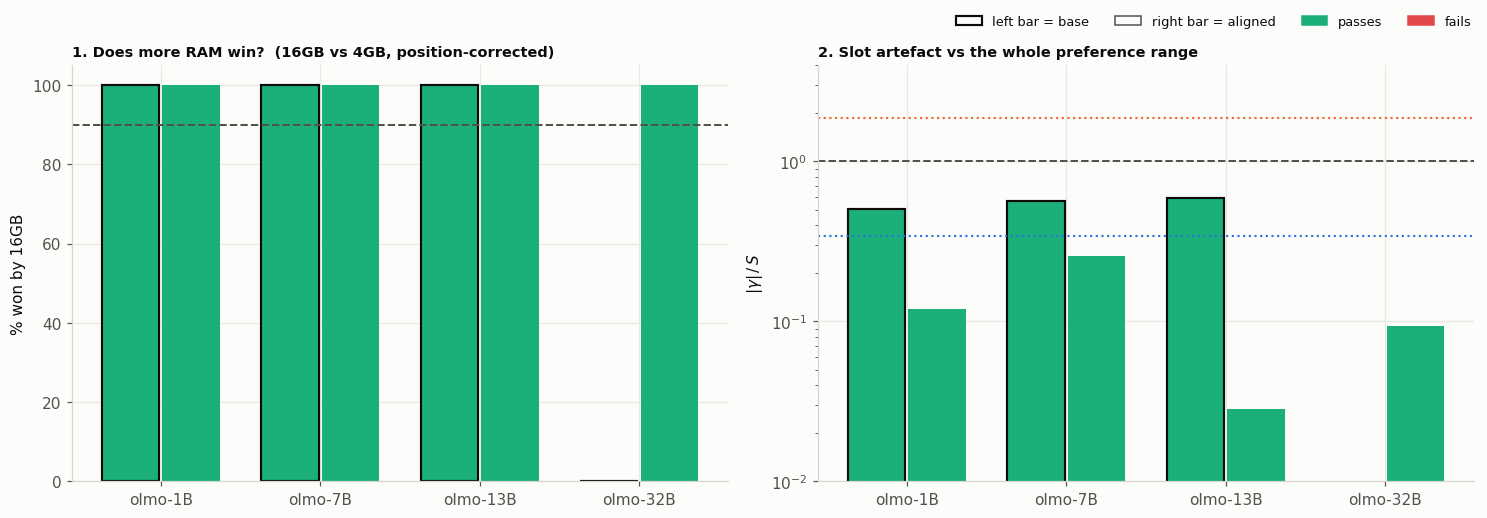

   model    kind  ram16_wins  gamma_over_S  slotA      S    r2  passes
 olmo-1B aligned       100.0         0.119 58.364  1.001 0.293    True
 olmo-7B aligned       100.0         0.257 63.465 13.118 0.824    True
olmo-13B aligned       100.0         0.028 42.081 17.474 0.901    True
olmo-32B aligned       100.0         0.094 39.818  9.272 0.907    True
 olmo-1B    base       100.0         0.502 70.758  0.266 0.066    True
 olmo-7B    base       100.0         0.569 84.131  1.240 0.503    True
olmo-13B    base       100.0         0.588 83.566  2.143 0.677    True

base models passing the gate: ['olmo-13B', 'olmo-1B', 'olmo-7B']
Every OLMo base model passes. All four gemma base models failed this same check.
Note |gamma|/S = 0.50-0.59 for OLMo base: comfortably usable, but noisier on position
than qwen base (0.06-0.34). OLMo sits between qwen and gemma, on the right side.


In [6]:
gate = []
for (fam, s), f in FITS.items():
    d = RUNS[(fam, s)]
    m = (d.score_a - d.score_b).values
    D = paired_D(d, "ram", "16GB", "4GB")
    gate.append(dict(model=f"olmo-{s}B", size=float(s),
                     kind="base" if fam.endswith("-pt") else "aligned",
                     ram16_wins=100 * (D > 0).mean(), gamma_over_S=abs(f.gamma_) / f.total_spread(),
                     S=f.total_spread(), gamma=f.gamma_, r2=f.r2_,
                     slotA=100 * (m > 0).mean(), n_pairs=len(D)))
G = pd.DataFrame(gate).sort_values(["kind", "size"])
G["passes"] = (G.ram16_wins >= 90) & (G.gamma_over_S < 1)

order = [f"olmo-{s}B" for s in OLMO_SIZES]
fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.5))
x = np.arange(len(order))
for ax, (col, ttl, ylab, thr, good_above) in zip(axes, [
        ("ram16_wins", "1. Does more RAM win?  (16GB vs 4GB, position-corrected)",
         "% won by 16GB", 90, True),
        ("gamma_over_S", r"2. Slot artefact vs the whole preference range",
         r"$|\gamma| \,/\, S$", 1.0, False)]):
    for i, kind in enumerate(["base", "aligned"]):
        sub = G[G.kind == kind].set_index("model").reindex(order)
        colr = [PASS_C if (v >= thr if good_above else v < thr) else FAIL_C for v in sub[col]]
        ax.bar(x + (i - .5) * .38, sub[col].fillna(0), .36, color=colr, zorder=2,
               edgecolor=INK if kind == "base" else "none", lw=1.4)
    ax.axhline(thr, color=INK_MUTED, ls="--", lw=1.3)
    ax.set_xticks(x, order)
    ax.set_ylabel(ylab)
    ax.set_title(ttl, loc="left", fontweight="bold", fontsize=9.5)
axes[1].set_yscale("log")
axes[1].set_ylim(0.01, 4)
# where qwen and gemma base models sat, for context
for v, lab, c in [(0.34, "qwen base worst (0.34)", "#2a78d6"), (1.87, "gemma base best (1.87)", "#eb6834")]:
    axes[1].axhline(v, color=c, ls=":", lw=1.4)
    axes[1].annotate(lab, (len(order) - .4, v), fontsize=7.5, color=c, va="bottom", ha="right")
fig.legend(handles=[Rectangle((0, 0), 1, 1, fc="none", ec=INK, lw=1.4),
                    Rectangle((0, 0), 1, 1, fc="none", ec=INK_MUTED),
                    Rectangle((0, 0), 1, 1, color=PASS_C), Rectangle((0, 0), 1, 1, color=FAIL_C)],
           labels=["left bar = base", "right bar = aligned", "passes", "fails"],
           loc="upper right", ncol=4, frameon=False, fontsize=8.5, bbox_to_anchor=(.995, 1.05))
fig.tight_layout()
save(fig, "o1_gate")
plt.show()

print(G[["model", "kind", "ram16_wins", "gamma_over_S", "slotA", "S", "r2", "passes"]]
      .round(3).to_string(index=False))
print(f"\nbase models passing the gate: {sorted(G[(G.kind=='base') & G.passes].model)}")
print("Every OLMo base model passes. All four gemma base models failed this same check.")
print("Note |gamma|/S = 0.50-0.59 for OLMo base: comfortably usable, but noisier on position")
print("than qwen base (0.06-0.34). OLMo sits between qwen and gemma, on the right side.")

---
# Step 2 — does the qwen result replicate?

One point per (feature level): 11 levels, unconstrained run only. Axes are the normalised weight
$\tilde{w} = w/S$, so a point on the diagonal means base and aligned give that level the same
share of their total preference range.

Only three panels: `olmo-pt 32B` never landed.

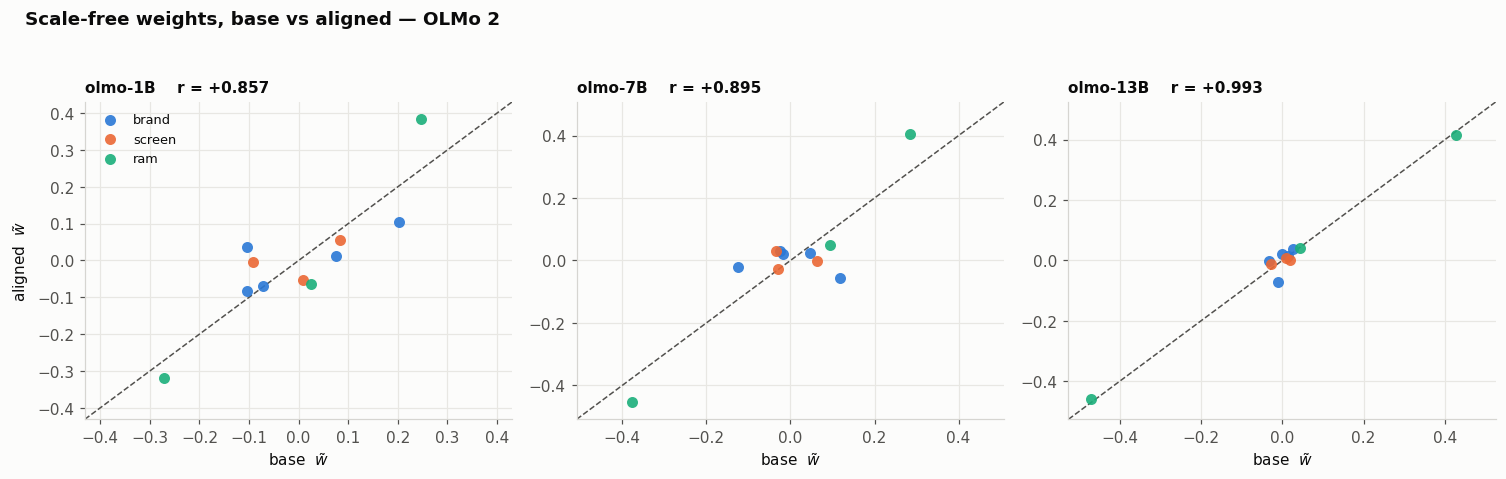

   model  size  r_all     p  r_brand  S_base  S_aligned  loudness
 olmo-1B   1.0  0.857 0.001    0.761   0.266      1.001     3.757
 olmo-7B   7.0  0.895 0.000   -0.310   1.240     13.118    10.575
olmo-13B  13.0  0.993 0.000    0.519   2.143     17.474     8.153

r rises with size: 0.857 -> 0.895 -> 0.993. The 13B pair matches qwen's 0.98-0.99.
The 1B pair is the weakest test: its BASE fit has R^2 = 0.066, essentially noise,
so read 0.857 as 'not inconsistent', not as evidence.

r_brand is unstable (+0.76 / -0.31 / +0.52) - brand is the smallest feature
(base range 0.08-0.30) and therefore the noisiest, exactly as in qwen.


In [7]:
pts = []
for s in PAIRS:
    fb, fa = FITS[("olmo-pt", s)], FITS[("olmo", s)]
    for f, lv in LEVELS.items():
        for l in lv:
            pts.append(dict(size=s, feat=f, lvl=l,
                            base=fb.normalised(f, l), aligned=fa.normalised(f, l)))
P = pd.DataFrame(pts)

fig, axes = plt.subplots(1, len(PAIRS), figsize=(4.6 * len(PAIRS), 4.4))
res = []
for ax, s in zip(np.atleast_1d(axes), PAIRS):
    sub = P[P["size"] == s]
    r, p = st.pearsonr(sub.base, sub.aligned)
    rb = st.pearsonr(sub[sub.feat == "brand"].base, sub[sub.feat == "brand"].aligned)[0]
    res.append(dict(model=f"olmo-{s}B", size=float(s), r_all=r, p=p, r_brand=rb,
                    S_base=FITS[("olmo-pt", s)].total_spread(),
                    S_aligned=FITS[("olmo", s)].total_spread()))
    lim = 1.12 * max(sub.base.abs().max(), sub.aligned.abs().max())
    ax.plot([-lim, lim], [-lim, lim], color=INK_MUTED, lw=1, ls="--", zorder=1)
    for f in LEVELS:
        t = sub[sub.feat == f]
        ax.scatter(t.base, t.aligned, s=52, color=FEATURE_COLOR[f], label=f,
                   alpha=.9, linewidths=0, zorder=3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"base  $\tilde{w}$")
    ax.set_title(f"olmo-{s}B    r = {r:+.3f}", loc="left", fontweight="bold", fontsize=10)
np.atleast_1d(axes)[0].set_ylabel(r"aligned  $\tilde{w}$")
np.atleast_1d(axes)[0].legend(frameon=False, fontsize=8.5, loc="upper left")
fig.suptitle("Scale-free weights, base vs aligned — OLMo 2", x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .94])
save(fig, "o2_replication")
plt.show()

RES = pd.DataFrame(res)
RES["loudness"] = RES.S_aligned / RES.S_base
print(RES.round(3).to_string(index=False))
print("\nr rises with size: 0.857 -> 0.895 -> 0.993. The 13B pair matches qwen's 0.98-0.99.")
print("The 1B pair is the weakest test: its BASE fit has R^2 = 0.066, essentially noise,")
print("so read 0.857 as 'not inconsistent', not as evidence.")
print("\nr_brand is unstable (+0.76 / -0.31 / +0.52) - brand is the smallest feature")
print("(base range 0.08-0.30) and therefore the noisiest, exactly as in qwen.")

---
# Step 3 — loudness, and where OLMo sits among the three families

$S$ is the model's whole preference range, $u(\text{best laptop}) - u(\text{worst laptop})$.
The loudness ratio $S_{\text{aligned}}/S_{\text{base}}$ is how much alignment turned the volume
up.

The right panel puts all three families on the gate axis together — the one number that decides
whether a family can be measured at all. It is the summary of where this line of work stands.

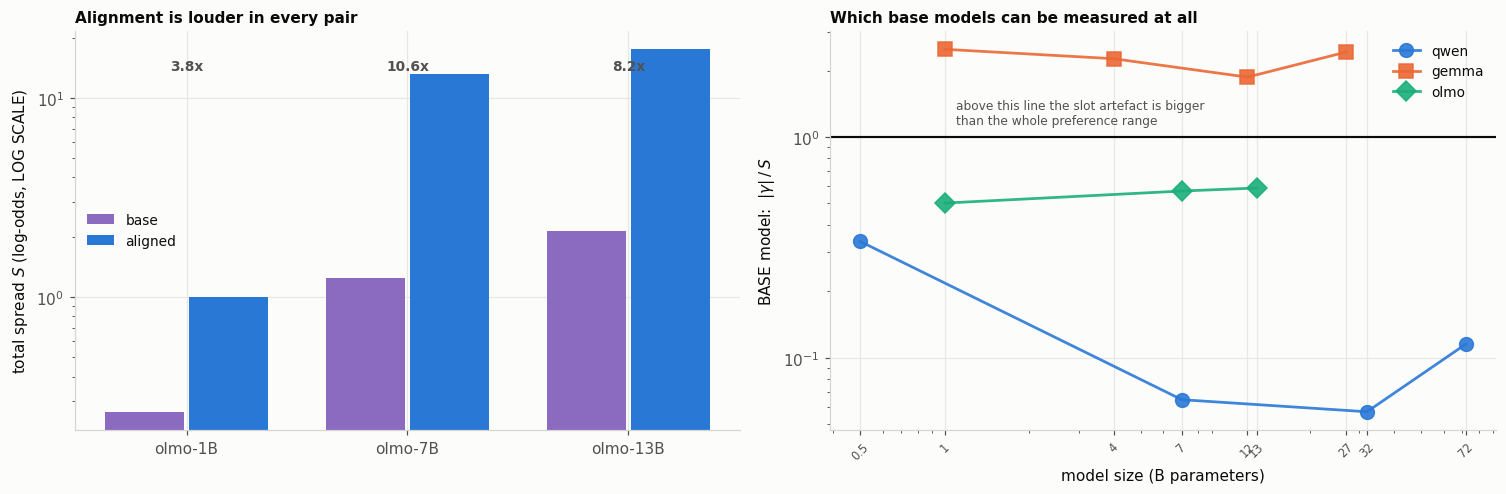

BASE models, |gamma|/S by family (lower = more content-driven):
                min          max
       gamma_over_S gamma_over_S
family                          
gemma         1.869        2.499
olmo          0.502        0.588
qwen          0.057        0.336

loudness, OLMo: 3.8x, 10.6x, 8.2x
for reference, qwen 7/32/72B was 9.3x / 14.2x / 10.0x


In [8]:
# reload qwen and gemma unconstrained runs for the cross-family panel.
# their ALIGNED runs predate the PMI change, so C must be recovered there; their base runs and
# all of OLMo were collected with PMI off, where C = 0 exactly.
def pmi_c(d):
    mx = max(d.score_a.max(), d.score_b.max())
    if mx <= 0:
        return 0.0, False                      # PMI off -> beta0 IS gamma
    tol = 0.01
    sat = min((d.score_a > d.score_a.max() - tol).mean(),
              (d.score_b > d.score_b.max() - tol).mean())
    return (d.score_b.max() - d.score_a.max() if sat >= 0.01 else np.nan), True

OTHER, _sk = load(["data/laptops_robustness", "data/laptops_robustness_gemma",
                   "data/laptops_robustness_pt"])
rows = []
for (fam, s), d in OTHER.items():
    base_fam = fam.replace("-pt", "")
    if base_fam not in ("qwen", "gemma"):
        continue
    c, on = pmi_c(d)
    f = FeatureBT(pmi_c=(0.0 if np.isnan(c) else c), r2_warn=None).fit(d)
    D = paired_D(d, "ram", "16GB", "4GB")
    rows.append(dict(family=base_fam, model=f"{base_fam}-{s}B", size=float(s),
                     kind="base" if fam.endswith("-pt") else "aligned",
                     gamma_over_S=abs(f.gamma_) / f.total_spread(),
                     ram16_wins=100 * (D > 0).mean(), S=f.total_spread(),
                     gamma_known=not np.isnan(c)))
for _, r in G.iterrows():
    rows.append(dict(family="olmo", model=r.model, size=r["size"], kind=r.kind,
                     gamma_over_S=r.gamma_over_S, ram16_wins=r.ram16_wins, S=r.S,
                     gamma_known=True))
ALL3 = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.6))

ax = axes[0]
lab = [f"olmo-{s}B" for s in PAIRS]
xx = np.arange(len(lab))
for i, (c, k) in enumerate([("S_base", "base"), ("S_aligned", "aligned")]):
    ax.bar(xx + (i - .5) * .38, RES.set_index("model").reindex(lab)[c], .36,
           color=KIND_COLOR[k], label=k, zorder=2)
for xi, v in zip(xx, RES.set_index("model").reindex(lab).loudness):
    ax.annotate(f"{v:.1f}x", (xi, ax.get_ylim()[1] * .75), ha="center", fontsize=9,
                fontweight="bold", color=INK_MUTED)
ax.set_yscale("log")
ax.set_xticks(xx, lab)
ax.set_ylabel("total spread $S$ (log-odds, LOG SCALE)")
ax.set_title("Alignment is louder in every pair", loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
b = ALL3[(ALL3.kind == "base") & ALL3.gamma_known]
for fam in ["qwen", "gemma", "olmo"]:
    t = b[b.family == fam].sort_values("size")
    ax.plot(t["size"], t.gamma_over_S, FAM_MARKER[fam], ls="-", color=FAM_COLOR[fam],
            ms=9, lw=1.8, label=fam, alpha=.9)
ax.axhline(1, color=INK, lw=1.4)
ax.annotate("above this line the slot artefact is bigger\nthan the whole preference range",
            (1.1, 1.15), fontsize=8, color=INK_MUTED)
ax.set_xscale("log"); ax.set_yscale("log")
# 12 and 13 are almost coincident on a log axis, so the labels are rotated to stay legible
ax.set_xticks([0.5, 1, 4, 7, 12, 13, 27, 32, 72],
              ["0.5", "1", "4", "7", "12", "13", "27", "32", "72"],
              fontsize=7.5, rotation=45)
ax.set_xlabel("model size (B parameters)")
ax.set_ylabel(r"BASE model:  $|\gamma| \,/\, S$")
ax.set_title("Which base models can be measured at all", loc="left", fontweight="bold",
             fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "o3_loudness_and_families")
plt.show()

print("BASE models, |gamma|/S by family (lower = more content-driven):")
print(b.pivot_table(index="family", values="gamma_over_S", aggfunc=["min", "max"]).round(3).to_string())
print("\nloudness, OLMo:", ", ".join(f"{v:.1f}x" for v in RES.loudness))
print("for reference, qwen 7/32/72B was 9.3x / 14.2x / 10.0x")

---
## Where this leaves the third family

| | qwen | gemma | **OLMo 2** |
|---|---|---|---|
| base models pass the gate | 4 / 4 | **0 / 4** | **3 / 3** |
| base $\|\gamma\|/S$ | 0.06 – 0.34 | 1.87 – 2.50 | 0.50 – 0.59 |
| scale-free agreement $r$ | 0.98 – 0.99 (7B+) | not measurable | 0.857 / 0.895 / **0.993** |
| loudness | 9.3 – 14.2x | not measurable | 3.8 / 10.6 / 8.2x |

**The finding replicates on a second usable family.** OLMo's 13B pair reaches `r = 0.993`, and
its loudness sits in qwen's range. gemma remains the odd one out, and OLMo makes that harder to
dismiss as "base models cannot be measured" — two of three families can.

**Read the size trend with care.** `r` rises 0.857 → 0.895 → 0.993, which is tempting, but the
1B base fit has `R² = 0.066` — its weights are close to noise, so a low `r` there is expected
whatever the truth is. Three points, one of them weak, is not a trend.

**`r` is leveraged by RAM.** With 11 points, the two RAM extremes sit near $\pm 0.45$ while every
brand and screen level clusters near 0, so they carry most of the correlation — visible in the
scatter above. That is why `r_brand` is reported separately, and why it is so much weaker. The
same caveat applies to qwen's 0.990: it says the *dominant* preference is shared, not that every
feature is.

**OLMo base sits between qwen and gemma on the gate** ($|\gamma|/S$ ≈ 0.5 against qwen's ≈ 0.1).
Usable, but the slot artefact is half the size of everything it prefers — worth remembering when
its numbers look noisier than qwen's.

### What is still needed

1. **`olmo-pt 32B`** — lost to the disk-full failure and not recovered in the rerun. Without it
   the largest pair is missing, which is where qwen's effect was clearest.
2. **Stage 2, the three contract runs** (24 jobs, commented out in `create_slurms.py`). Nothing
   here touches adherence, κ, or the Apple decay, because those all need a contract. The gate is
   passed, so stage 2 is now worth launching.